<a href="https://colab.research.google.com/github/AI-fanatic24/machine-learning-foundations/blob/main/Drug_Classification_XGBClassifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/drug200.csv')

In [ ]:
df

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY
...,...,...,...,...,...,...
195,56,F,LOW,HIGH,11.567,drugC
196,16,M,LOW,HIGH,12.006,drugC
197,52,M,NORMAL,HIGH,9.894,drugX
198,23,M,NORMAL,NORMAL,14.020,drugX


In [ ]:
df.columns

Index(['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K', 'Drug'], dtype='object')

In [ ]:
one_hot_features = ['Sex','BP','Cholesterol']

In [ ]:
df = pd.get_dummies(data=df,columns=one_hot_features,prefix=one_hot_features)

In [ ]:
df

,Age,Na_to_K,Drug,Sex_F,Sex_M,BP_HIGH,BP_LOW,BP_NORMAL,Cholesterol_HIGH,Cholesterol_NORMAL
0,23,25.355,drugY,1,0,1,0,0,1,0
1,47,13.093,drugC,0,1,0,1,0,1,0
2,47,10.114,drugC,0,1,0,1,0,1,0
3,28,7.798,drugX,1,0,0,0,1,1,0
4,61,18.043,drugY,1,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...
195,56,11.567,drugC,1,0,0,1,0,1,0
196,16,12.006,drugC,0,1,0,1,0,1,0
197,52,9.894,drugX,0,1,0,0,1,1,0
198,23,14.020,drugX,0,1,0,0,1,0,1


In [ ]:
df.loc[df["Drug"] == "drugA","Drug"] = 0 #A
df.loc[df["Drug"] == "drugB","Drug"] = 1 #B
df.loc[df["Drug"] == "drugC","Drug"] = 2 #C
df.loc[df["Drug"] == "drugX","Drug"] = 3 #X
df.loc[df["Drug"] == "drugY","Drug"] = 4 #Y

In [ ]:
df

,Age,Na_to_K,Drug,Sex_F,Sex_M,BP_HIGH,BP_LOW,BP_NORMAL,Cholesterol_HIGH,Cholesterol_NORMAL
0,23,25.355,4,1,0,1,0,0,1,0
1,47,13.093,2,0,1,0,1,0,1,0
2,47,10.114,2,0,1,0,1,0,1,0
3,28,7.798,3,1,0,0,0,1,1,0
4,61,18.043,4,1,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...
195,56,11.567,2,1,0,0,1,0,1,0
196,16,12.006,2,0,1,0,1,0,1,0
197,52,9.894,3,0,1,0,0,1,1,0
198,23,14.020,3,0,1,0,0,1,0,1


In [ ]:
features = [x for x in df.columns if x not in ['Drug']]

In [ ]:
X_train,X_,y_train,y_ = train_test_split(df[features],df['Drug'],test_size=0.40,random_state=1)
X_cv,X_test,y_cv,y_test = train_test_split(X_,y_,test_size=0.50,random_state=1)
del X_,y_

In [ ]:
X_train = np.array(X_train,dtype='float32')
y_train = np.array(y_train,dtype='float32').reshape(-1,1)
X_cv = np.array(X_cv,dtype='float32')
y_cv = np.array(y_cv,dtype='float32').reshape(-1,1)
X_test = np.array(X_test,dtype='float32')
y_test = np.array(y_test,dtype='float32').reshape(-1,1)

In [ ]:
print("X_train.shape",X_train.shape)
print("y_train.shape",y_train.shape)
print("X_cv.shape",X_cv.shape)
print("y_cv.shape",y_cv.shape)
print("X_test.shape",X_test.shape)
print("y_test.shape",y_test.shape)

X_train.shape (120, 9)
y_train.shape (120, 1)
X_cv.shape (40, 9)
y_cv.shape (40, 1)
X_test.shape (40, 9)
y_test.shape (40, 1)


In [ ]:
xgb_model = XGBClassifier(n_estimators=300,learning_rate=0.02,random_state=1)
xgb_model.fit(X_train,y_train,eval_set=[(X_cv,y_cv)],early_stopping_rounds=5)

[0]	validation_0-mlogloss:1.57095
[1]	validation_0-mlogloss:1.53413
[2]	validation_0-mlogloss:1.49886
[3]	validation_0-mlogloss:1.46502
[4]	validation_0-mlogloss:1.43253
[5]	validation_0-mlogloss:1.40129
[6]	validation_0-mlogloss:1.37123
[7]	validation_0-mlogloss:1.34227
[8]	validation_0-mlogloss:1.31435
[9]	validation_0-mlogloss:1.28741
[10]	validation_0-mlogloss:1.26140
[11]	validation_0-mlogloss:1.23626
[12]	validation_0-mlogloss:1.21195
[13]	validation_0-mlogloss:1.18842
[14]	validation_0-mlogloss:1.16565
[15]	validation_0-mlogloss:1.14359
[16]	validation_0-mlogloss:1.12221
[17]	validation_0-mlogloss:1.10147
[18]	validation_0-mlogloss:1.08136
[19]	validation_0-mlogloss:1.06184
[20]	validation_0-mlogloss:1.04288
[21]	validation_0-mlogloss:1.02447
[22]	validation_0-mlogloss:1.00658
[23]	validation_0-mlogloss:0.98919
[24]	validation_0-mlogloss:0.97228
[25]	validation_0-mlogloss:0.95583
[26]	validation_0-mlogloss:0.93983
[27]	validation_0-mlogloss:0.92426
[28]	validation_0-mlogloss:0.9

/usr/local/lib/python3.10/dist-packages/xgboost/sklearn.py:889: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(


[33]	validation_0-mlogloss:0.83900
[34]	validation_0-mlogloss:0.82603
[35]	validation_0-mlogloss:0.81339
[36]	validation_0-mlogloss:0.80105
[37]	validation_0-mlogloss:0.78903
[38]	validation_0-mlogloss:0.77730
[39]	validation_0-mlogloss:0.76620
[40]	validation_0-mlogloss:0.75538
[41]	validation_0-mlogloss:0.74482
[42]	validation_0-mlogloss:0.73451
[43]	validation_0-mlogloss:0.72445
[44]	validation_0-mlogloss:0.71463
[45]	validation_0-mlogloss:0.70505
[46]	validation_0-mlogloss:0.69569
[47]	validation_0-mlogloss:0.68655
[48]	validation_0-mlogloss:0.67763
[49]	validation_0-mlogloss:0.66892
[50]	validation_0-mlogloss:0.66040
[51]	validation_0-mlogloss:0.65209
[52]	validation_0-mlogloss:0.64397
[53]	validation_0-mlogloss:0.63603
[54]	validation_0-mlogloss:0.62828
[55]	validation_0-mlogloss:0.62070
[56]	validation_0-mlogloss:0.61330
[57]	validation_0-mlogloss:0.60607
[58]	validation_0-mlogloss:0.59900
[59]	validation_0-mlogloss:0.59209
[60]	validation_0-mlogloss:0.58533
[61]	validation_0-ml

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.02, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, objective='multi:softprob', ...)

In [ ]:
yhat_train = xgb_model.predict(X_train)
yhat_cv = xgb_model.predict(X_cv)
yhat_test = xgb_model.predict(X_test)

In [ ]:
yhat_train = np.array(yhat_train).reshape(-1,1)
yhat_cv = np.array(yhat_cv).reshape(-1,1)
yhat_test = np.array(yhat_test).reshape(-1,1)

In [ ]:
print("Train Accuracy:",accuracy_score(yhat_train,y_train))
print("Validation Accuracy:",accuracy_score(yhat_cv,y_cv))
print("Test Accuracy:",accuracy_score(yhat_test,y_test))

Train Accuracy: 1.0
Validation Accuracy: 0.9
Test Accuracy: 1.0


In [ ]:
for i in range(yhat_test.shape[0]):
  print("Prediction:",yhat_test[i],"  Actual Value:",y_test[i] )

Prediction: [4]   Actual Value: [4.]
Prediction: [4]   Actual Value: [4.]
Prediction: [4]   Actual Value: [4.]
Prediction: [0]   Actual Value: [0.]
Prediction: [3]   Actual Value: [3.]
Prediction: [3]   Actual Value: [3.]
Prediction: [4]   Actual Value: [4.]
Prediction: [4]   Actual Value: [4.]
Prediction: [4]   Actual Value: [4.]
Prediction: [2]   Actual Value: [2.]
Prediction: [0]   Actual Value: [0.]
Prediction: [0]   Actual Value: [0.]
Prediction: [0]   Actual Value: [0.]
Prediction: [1]   Actual Value: [1.]
Prediction: [3]   Actual Value: [3.]
Prediction: [3]   Actual Value: [3.]
Prediction: [4]   Actual Value: [4.]
Prediction: [3]   Actual Value: [3.]
Prediction: [4]   Actual Value: [4.]
Prediction: [4]   Actual Value: [4.]
Prediction: [4]   Actual Value: [4.]
Prediction: [0]   Actual Value: [0.]
Prediction: [3]   Actual Value: [3.]
Prediction: [3]   Actual Value: [3.]
Prediction: [4]   Actual Value: [4.]
Prediction: [3]   Actual Value: [3.]
Prediction: [3]   Actual Value: [3.]
P

In [ ]:
y_test = np.array(y_test,dtype='float32').reshape(-1)
yhat_test = yhat_test.reshape(-1,1)

In [ ]:
print("yhat_test.shape:",yhat_test.shape)
print("y_test.shape:",y_test.shape)

yhat_test.shape: (40, 1)
y_test.shape: (40,)


In [ ]:
output = pd.DataFrame({'Prediction' : yhat_test, 'Actual Value' : y_test})

In [ ]:
output

,Prediction,Actual Value
0,4,4.0
1,4,4.0
2,4,4.0
3,0,0.0
4,3,3.0
5,3,3.0
6,4,4.0
7,4,4.0
8,4,4.0
9,2,2.0


In [ ]:
output.loc[output["Prediction"] == 0,"Prediction"] = "DrugA"
output.loc[output["Prediction"] == 1,"Prediction"] = "DrugB"
output.loc[output["Prediction"] == 2,"Prediction"] = "DrugC"
output.loc[output["Prediction"] == 3,"Prediction"] = "DrugX"
output.loc[output["Prediction"] == 4,"Prediction"] = "DrugY"

output.loc[output["Actual Value"] == 0,"Actual Value"] = "DrugA"
output.loc[output["Actual Value"] == 1,"Actual Value"] = "DrugB"
output.loc[output["Actual Value"] == 2,"Actual Value"] = "DrugC"
output.loc[output["Actual Value"] == 3,"Actual Value"] = "DrugX"
output.loc[output["Actual Value"] == 4,"Actual Value"] = "DrugY"

In [ ]:
output

,Prediction,Actual Value
0,DrugY,DrugY
1,DrugY,DrugY
2,DrugY,DrugY
3,DrugA,DrugA
4,DrugX,DrugX
5,DrugX,DrugX
6,DrugY,DrugY
7,DrugY,DrugY
8,DrugY,DrugY
9,DrugC,DrugC


In [ ]:
yhat_test = yhat_test.reshape(-1,1)
y_test = y_test.reshape(-1,1)

In [ ]:
min_samples_split_list = [2,10,30,50,100,200,300,500]
max_depth_list = [1,2,3,4,8,16,32,64,None]

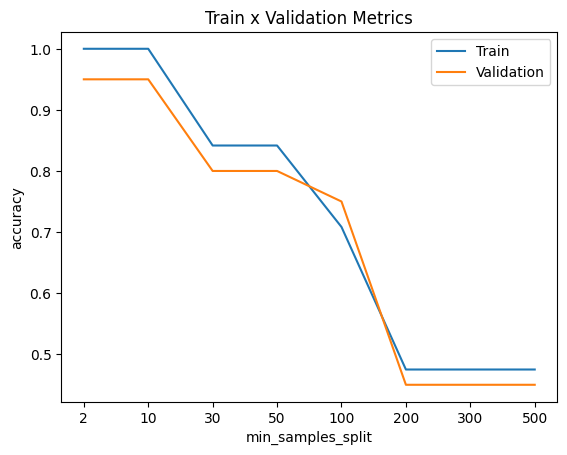

In [ ]:
accuracy_train_list= []
accuracy_val_list =[]
for min_samples_split in min_samples_split_list:
  model = DecisionTreeClassifier(min_samples_split=min_samples_split,random_state=1).fit(X_train,y_train)

  predictions_train = model.predict(X_train)
  predictions_val = model.predict(X_cv)

  accuracy_train = accuracy_score(predictions_train,y_train)
  accuracy_val = accuracy_score(predictions_val,y_cv)

  accuracy_train_list.append(accuracy_train)
  accuracy_val_list.append(accuracy_val)

plt.title("Train x Validation Metrics")
plt.xlabel("min_samples_split")
plt.ylabel("accuracy")
plt.xticks(ticks=range(len(min_samples_split_list)),labels=min_samples_split_list)
plt.plot(accuracy_train_list)
plt.plot(accuracy_val_list)
plt.legend(['Train','Validation'])



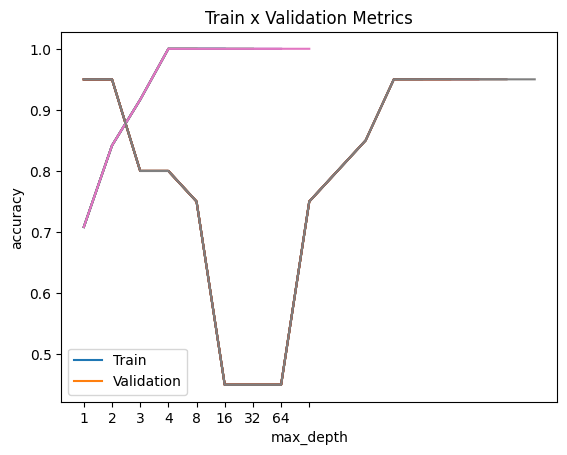

In [ ]:
accuracy_train_list = []
accuarcy_val_list = []
for max_depth in max_depth_list:
  model = DecisionTreeClassifier(max_depth=max_depth,random_state=1).fit(X_train,y_train)

  predictions_train = model.predict(X_train)
  predictions_val = model.predict(X_cv)

  accuracy_train = accuracy_score(predictions_train,y_train)
  accuracy_val = accuracy_score(predictions_val,y_cv)
  accuracy_train_list.append(accuracy_train)
  accuracy_val_list.append(accuracy_val)

  plt.title("Train x Validation Metrics")
  plt.xlabel("max_depth")
  plt.ylabel("accuracy")
  plt.xticks(ticks=range(len(max_depth_list)),labels=max_depth_list)
  plt.plot(accuracy_train_list)
  plt.plot(accuracy_val_list)
  plt.legend(['Train','Validation'])

In [ ]:
model = DecisionTreeClassifier(min_samples_split=2,max_depth=4,random_state=1).fit(X_train,y_train)

In [ ]:
yhat = model.predict(X_test)
print("Test accuarcy:",accuracy_score(yhat,y_test))

Test accuarcy: 1.0


In [ ]:
yhat = model.predict(X_cv)
print("Validation accuracy:",accuracy_score(yhat,y_cv))

Validation accuracy: 0.95


In [ ]:
yhat = model.predict(X_train)
print("Train accuracy:",accuracy_score(yhat,y_train))

Train accuracy: 1.0
